# MLflow Demo — Experiment Tracking Workflow

This notebook demonstrates a clean **machine learning workflow** integrated with the platform’s **MLflow tracking infrastructure**.

## What this notebook covers

- Loading a built-in classification dataset (scikit-learn)
- Creating a reproducible train/test workflow
- Training and comparing baseline models
- Evaluating models using standard classification metrics
- Logging parameters, metrics, and artifacts to MLflow
- Inspecting and comparing runs in the MLflow UI

## Platform services used

- **MLflow Tracking Server:**
- **Backend store:** PostgreSQL (experiment metadata)
- **Artifact storage:** MinIO (S3-compatible object storage)


## Why this example is useful

This example demonstrates the core MLOps loop:

**dataset → training → evaluation → experiment tracking → artifact storage**

It shows how model experiments can be tracked, compared, and reproduced using a structured platform setup.


## Relationship to other examples

This demo focuses on **experiment tracking and reproducibility**,
while the RAG example demonstrates **retrieval-based AI pipelines**.

Together, they represent two core patterns of modern AI systems:
- classical ML workflows
- LLM-based applications


# Section 1: Setup and Imports

Import required libraries and define core configuration for MLflow tracking and experiment execution.

## Overview

This section initializes the environment and loads core dependencies used for:

- data handling (`pandas`, `numpy`)
- model training and evaluation (`scikit-learn`)
- experiment tracking (`mlflow`)
- artifact generation (`matplotlib`)

It also configures the MLflow tracking URI and experiment name.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
from dotenv import load_dotenv
from tempfile import TemporaryDirectory
from textwrap import dedent


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import mlflow
import mlflow.sklearn

print("Imports loaded successfully")
print(f"MLflow version: {mlflow.__version__}")

Imports loaded successfully
MLflow version: 2.9.2


## Configuration

We define a small configuration block up front so the notebook is easy to adapt.

A few notes:

- `MLFLOW_TRACKING_URI` is the API endpoint used by the Python client
- `MLFLOW_UI_URL` is the browser-friendly UI URL
- `EXPERIMENT_NAME` groups related runs
- `RANDOM_STATE` keeps the workflow reproducible


In [2]:
# -------------------------------------------------------
# Load platform environment variables
# -------------------------------------------------------

ENV_FILE = Path("../../config/env/.env")

if ENV_FILE.exists():
    load_dotenv(ENV_FILE)
    print(f"Loaded environment variables from: {ENV_FILE}")
else:
    print(f"Environment file not found: {ENV_FILE}")

# -------------------------------------------------------
# MLflow configuration
# -------------------------------------------------------


MLFLOW_HOST = os.getenv("MLFLOW_HOST", "mlflow.localhost")
MLFLOW_UI_URL = f"http://{MLFLOW_HOST}"
MLFLOW_TRACKING_URI = "http://mlflow.localhost"
EXPERIMENT_NAME = "platform-mlflow-demo"

# -------------------------------------------------------
# MinIO (S3 artifact storage)
# -------------------------------------------------------

MINIO_ROOT_USER = os.getenv("MINIO_ROOT_USER")
MINIO_ROOT_PASSWORD = os.getenv("MINIO_ROOT_PASSWORD")
MLFLOW_S3_ENDPOINT_URL = "http://localhost:9000"

if not MINIO_ROOT_USER or not MINIO_ROOT_PASSWORD:
    raise ValueError(
        "Missing MinIO credentials. Ensure MINIO_ROOT_USER and MINIO_ROOT_PASSWORD are defined in ../../config/env/.env"
    )

# Map platform variables to boto / MLflow expected variables
os.environ["MLFLOW_S3_ENDPOINT_URL"] = MLFLOW_S3_ENDPOINT_URL
os.environ["AWS_ACCESS_KEY_ID"] = MINIO_ROOT_USER
os.environ["AWS_SECRET_ACCESS_KEY"] = MINIO_ROOT_PASSWORD

# -------------------------------------------------------
# Dataset configuration
# -------------------------------------------------------

DATASET_NAME = "breast_cancer"
TEST_SIZE = 0.20
RANDOM_STATE = 42


Loaded environment variables from: ..\..\config\env\.env


In [3]:
# -------------------------------------------------------
# Apply MLflow configuration
# -------------------------------------------------------

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Configuration")
print("-" * 60)
print(f"Tracking URI   : {MLFLOW_TRACKING_URI}")
print(f"MLflow UI      : {MLFLOW_UI_URL}")
print(f"Experiment     : {EXPERIMENT_NAME}")
print(f"Dataset        : {DATASET_NAME}")
print(f"Test size      : {TEST_SIZE:.0%}")
print(f"Random state   : {RANDOM_STATE}")
print(f"S3 endpoint    : {MLFLOW_S3_ENDPOINT_URL}")
print(f"MinIO user     : {'set' if MINIO_ROOT_USER else 'missing'}")
print(f"MinIO password : {'set' if MINIO_ROOT_PASSWORD else 'missing'}")

Configuration
------------------------------------------------------------
Tracking URI   : http://mlflow.localhost
MLflow UI      : http://mlflow.localhost
Experiment     : platform-mlflow-demo
Dataset        : breast_cancer
Test size      : 20%
Random state   : 42
S3 endpoint    : http://localhost:9000
MinIO user     : set
MinIO password : set


# Section 2:  Connect to MLflow

This step validates the tracking configuration and ensures the target experiment exists.


In [4]:
# -------------------------------------------------------
# Connect to MLflow
# -------------------------------------------------------

import requests

print("Connecting to MLflow...")

# -------------------------------------------------------
# Validate MLflow is reachable
# -------------------------------------------------------

try:
    response = requests.get(MLFLOW_TRACKING_URI, timeout=5)
    print(f" - Connected to MLflow: {MLFLOW_TRACKING_URI} (status={response.status_code})")
except Exception as exc:
    raise RuntimeError(
        "Failed to connect to MLflow. "
        "Make sure the platform is running, e.g. .\\scripts\\windows\\up-tools.ps1"
    ) from exc

# -------------------------------------------------------
# Ensure experiment exists
# -------------------------------------------------------

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    print(f" - Created MLflow experiment: {EXPERIMENT_NAME} (id={experiment_id})")
else:
    experiment_id = experiment.experiment_id
    print(f" - Using existing MLflow experiment: {EXPERIMENT_NAME} (id={experiment_id})")

mlflow.set_experiment(EXPERIMENT_NAME)

# -------------------------------------------------------
# Add experiment tags
# -------------------------------------------------------

client = mlflow.tracking.MlflowClient()

client.set_experiment_tag(experiment_id, "project", "ai-platform")
client.set_experiment_tag(experiment_id, "example", "mlflow-demo")
client.set_experiment_tag(experiment_id, "workflow", "classical-ml")
client.set_experiment_tag(experiment_id, "artifact_store", "minio")
client.set_experiment_tag(experiment_id, "tracking_backend", "postgresql")

print(" - Experiment tags applied")

Connecting to MLflow...
 - Connected to MLflow: http://mlflow.localhost (status=200)
 - Using existing MLflow experiment: platform-mlflow-demo (id=1)
 - Experiment tags applied


# Section 3: Load and Inspect the Dataset

Load the dataset, create a structured DataFrame, and inspect its shape, features, and target labels before training.## 3. Load and inspect the dataset

We use the built-in **breast cancer classification** dataset from scikit-learn.

Why this dataset?

- It is more realistic than Iris
- It requires no external download
- It supports a clean binary classification example with meaningful metrics


In [5]:
# -------------------------------------------------------
# Load dataset
# -------------------------------------------------------

if DATASET_NAME == "breast_cancer":
    dataset = load_breast_cancer()
else:
    raise ValueError(f"Unsupported dataset: {DATASET_NAME}")

X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")

label_mapping = {
    0: dataset.target_names[0],
    1: dataset.target_names[1],
}

df = X.copy()
df["target"] = y.map(label_mapping)

summary_df = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values
})

print("Dataset loaded")
print("-" * 60)
print(f"Dataset        : {DATASET_NAME}")
print(f"Samples        : {X.shape[0]}")
print(f"Features       : {X.shape[1]}")
print(f"Target classes : {list(dataset.target_names)}")

print("\nClass counts:")
print(y.map(label_mapping).value_counts())

print("\nFeature summary:")
display(summary_df.head())

print("\nPreview:")
display(df.head())

Dataset loaded
------------------------------------------------------------
Dataset        : breast_cancer
Samples        : 569
Features       : 30
Target classes : ['malignant', 'benign']

Class counts:
target
benign       357
malignant    212
Name: count, dtype: int64

Feature summary:


,feature,dtype
0,mean radius,float64
1,mean texture,float64
2,mean perimeter,float64
3,mean area,float64
4,mean smoothness,float64



Preview:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


# Section 4: Train/Test Split

Split the dataset into training and test sets to create a reproducible evaluation workflow.

## Step 4.1 – Create the Split

Use a fixed random state and stratified sampling to preserve class balance across train and test sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train/test split complete")
print("-" * 60)
print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print()
print("Target distribution (train):")
print(y_train.map(label_mapping).value_counts())
print()
print("Target distribution (test):")
print(y_test.map(label_mapping).value_counts())

Train/test split complete
------------------------------------------------------------
Train shape : (455, 30)
Test shape  : (114, 30)

Target distribution (train):
target
benign       285
malignant    170
Name: count, dtype: int64

Target distribution (test):
target
benign       72
malignant    42
Name: count, dtype: int64


## Step 4.2 – Inspect Split Balance

Verify that the class distribution remains stable after the split.

In [7]:
class_order = ["malignant", "benign"]

train_dist = y_train.map(label_mapping).value_counts().reindex(class_order)
test_dist = y_test.map(label_mapping).value_counts().reindex(class_order)

split_summary = pd.DataFrame({
    "train": train_dist,
    "test": test_dist,
})

print("Class distribution after split:")
display(split_summary)


Class distribution after split:


,train,test
target,,
malignant,170,42
benign,285,72


# Section 5: Evaluation and Artifact Utilities

Define reusable helper functions for metric computation, report generation, and artifact creation before training models.


In [8]:
# =======================================================
# Section 5: Evaluation and Artifact Utilities
# =======================================================

def compute_classification_metrics(y_true, y_pred, y_pred_proba_malignant):
    y_true_malignant = (y_true == 0).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_malignant": precision_score(y_true, y_pred, pos_label=0),
        "recall_malignant": recall_score(y_true, y_pred, pos_label=0),
        "f1_malignant": f1_score(y_true, y_pred, pos_label=0),
        "precision_benign": precision_score(y_true, y_pred, pos_label=1),
        "recall_benign": recall_score(y_true, y_pred, pos_label=1),
        "f1_benign": f1_score(y_true, y_pred, pos_label=1),
        "roc_auc_malignant": roc_auc_score(y_true_malignant, y_pred_proba_malignant),
    }


def save_confusion_matrix(y_true, y_pred, output_path: Path, title: str):
    """Create and save a confusion matrix plot for MLflow artifact logging."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["malignant", "benign"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.close(fig)


def write_text_artifact(output_path: Path, text: str):
    """Write a small text artifact to disk before logging it to MLflow."""
    output_path.write_text(text, encoding="utf-8")


def save_feature_importance_plot(importances_df: pd.DataFrame, output_path: Path, title: str):
    """Create and save a feature importance chart."""
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(importances_df["feature"], importances_df["importance"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.close(fig)


### Evaluation focus

This demo treats **malignant** as the primary positive class for model comparison.
That makes the logged recall, F1, and ROC interpretation more aligned with a medical screening use case, where missing malignant cases is usually more costly than incorrectly flagging benign ones.


# Section 6: Train, Evaluate, and Log Models

Train candidate models, evaluate them on the test set, and log metrics, models, and artifacts to MLflow.

In [9]:
# =======================================================
# Section 6: Train, Evaluate, and Log Models
# =======================================================

def train_evaluate_and_log_model(
    model_name: str,
    estimator,
    X_train,
    X_test,
    y_train,
    y_test,
    feature_names,
    dataset_name: str,
    experiment_notes: str = "",
):
    """Train a model, evaluate it, and log metrics, model, and artifacts to MLflow."""

    print(f"\n{'=' * 80}")
    print(f"Training model: {model_name}")
    print(f"{'=' * 80}")

    estimator.fit(X_train, y_train)

    y_pred = estimator.predict(X_test)

    # Class 0 = malignant, class 1 = benign
    # Use malignant probabilities if you want evaluation centered on malignant detection.
    y_pred_proba_malignant = estimator.predict_proba(X_test)[:, 0]

    metrics = compute_classification_metrics(
        y_test,
        y_pred,
        y_pred_proba_malignant,
    )

    print("Evaluation metrics")
    print("-" * 60)
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name:>20}: {metric_value:.4f}")

    with TemporaryDirectory() as tmp_dir:
        tmp_path = Path(tmp_dir)

        cm_path = tmp_path / f"{model_name}_confusion_matrix.png"
        report_path = tmp_path / f"{model_name}_classification_report.txt"
        metadata_path = tmp_path / f"{model_name}_run_notes.txt"

        save_confusion_matrix(
            y_test,
            y_pred,
            cm_path,
            title=f"Confusion Matrix — {model_name}",
        )

        report_text = classification_report(
            y_test,
            y_pred,
            target_names=["malignant", "benign"],
        )
        write_text_artifact(report_path, report_text)

        note_text = dedent(f"""\
        Model name: {model_name}
        Dataset: {dataset_name}
        Test size: {TEST_SIZE}
        Random state: {RANDOM_STATE}

        Notes:
        {experiment_notes if experiment_notes else "No additional notes."}
        """)
        write_text_artifact(metadata_path, note_text)

        with mlflow.start_run(run_name=model_name) as run:
            mlflow.log_param("dataset_name", dataset_name)
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("test_size", TEST_SIZE)
            mlflow.log_param("random_state", RANDOM_STATE)
            mlflow.log_param("feature_count", X_train.shape[1])
            mlflow.log_param("primary_positive_class", "malignant")
            mlflow.log_param("train_rows", len(X_train))
            mlflow.log_param("test_rows", len(X_test))
            mlflow.log_param("train_malignant_count", int((y_train == 0).sum()))
            mlflow.log_param("train_benign_count", int((y_train == 1).sum()))
            mlflow.log_param("test_malignant_count", int((y_test == 0).sum()))
            mlflow.log_param("test_benign_count", int((y_test == 1).sum()))

            mlflow.set_tag("run_type", "training")
            mlflow.set_tag("model_family", model_name)
            mlflow.set_tag("dataset", dataset_name)
            mlflow.set_tag("demo_type", "classical_ml_baseline")

            for param_name, param_value in estimator.get_params().items():
                if isinstance(param_value, (str, int, float, bool)) or param_value is None:
                    mlflow.log_param(param_name, param_value)

            mlflow.log_metrics(metrics)

            input_example = X_test.head(3)
            mlflow.sklearn.log_model(
                sk_model=estimator,
                artifact_path="model",
                input_example=input_example,
            )

            mlflow.log_artifact(str(cm_path), artifact_path="evaluation")
            mlflow.log_artifact(str(report_path), artifact_path="evaluation")
            mlflow.log_artifact(str(metadata_path), artifact_path="metadata")

            if hasattr(estimator, "named_steps"):
                final_step = list(estimator.named_steps.values())[-1]
            else:
                final_step = estimator

            if hasattr(final_step, "feature_importances_"):
                importances = (
                    pd.DataFrame({
                        "feature": feature_names,
                        "importance": final_step.feature_importances_,
                    })
                    .sort_values("importance", ascending=False)
                    .head(15)
                )

                fi_path = tmp_path / f"{model_name}_feature_importance.png"

                save_feature_importance_plot(
                    importances,
                    fi_path,
                    title=f"Top Feature Importance — {model_name}",
                )

                mlflow.log_artifact(str(fi_path), artifact_path="evaluation")

            run_id = run.info.run_id

    print(f"Logged run to MLflow: {run_id}")

    return {
        "model_name": model_name,
        "estimator": estimator,
        "metrics": metrics,
        "run_id": run_id,
    }


### MLflow run structure

Each model is logged as a separate MLflow training run, including parameters, metrics, model artifact, confusion matrix, and supporting notes.
A separate summary run is then used for cross-model comparison artifacts such as the comparison chart, ROC curve, coefficient chart, and comparison CSV.


# Section 7: Define Candidate Models

We define two baseline models to compare linear and non-linear approaches for binary classification.

These models provide a strong starting point before moving to more advanced techniques.

### Logistic Regression

A strong linear baseline for tabular binary classification.
It benefits from feature scaling and provides interpretable coefficients.

### Random Forest

A robust non-linear ensemble model that captures complex relationships.
It performs well out of the box and provides feature importance insights.


In [10]:
logistic_regression_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
                solver="lbfgs",
            ),
        ),
    ]
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Models configured")
print("-" * 60)
print("1. Logistic Regression + StandardScaler")
print("   - max_iter=1000")
print("   - solver=lbfgs")

print("2. Random Forest")
print("   - n_estimators=200")
print("   - max_depth=10")
print("   - min_samples_split=4")

Models configured
------------------------------------------------------------
1. Logistic Regression + StandardScaler
   - max_iter=1000
   - solver=lbfgs
2. Random Forest
   - n_estimators=200
   - max_depth=10
   - min_samples_split=4


# Session 8: Run Experiments and Log to MLflow

Train each candidate model, evaluate performance on the test set, and log metrics, models, and artifacts to MLflow for comparison.

In [11]:
results = []

# -------------------------------------------------------
# Logistic Regression
# -------------------------------------------------------

lr_result = train_evaluate_and_log_model(
    model_name="logistic_regression",
    estimator=logistic_regression_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feature_names=X.columns,
    dataset_name=DATASET_NAME,
    experiment_notes="Baseline linear model with scaling",
)

results.append(lr_result)

# -------------------------------------------------------
# Random Forest
# -------------------------------------------------------

rf_result = train_evaluate_and_log_model(
    model_name="random_forest",
    estimator=random_forest_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feature_names=X.columns,
    dataset_name=DATASET_NAME,
    experiment_notes="Non-linear ensemble baseline",
)

results.append(rf_result)


Training model: logistic_regression
Evaluation metrics
------------------------------------------------------------
            accuracy: 0.9825
 precision_malignant: 0.9762
    recall_malignant: 0.9762
        f1_malignant: 0.9762
    precision_benign: 0.9861
       recall_benign: 0.9861
           f1_benign: 0.9861
   roc_auc_malignant: 0.9954
Logged run to MLflow: 6e047ef328d449c399e8c15f216f3584

Training model: random_forest
Evaluation metrics
------------------------------------------------------------
            accuracy: 0.9474
 precision_malignant: 0.9286
    recall_malignant: 0.9286
        f1_malignant: 0.9286
    precision_benign: 0.9583
       recall_benign: 0.9583
           f1_benign: 0.9583
   roc_auc_malignant: 0.9937
Logged run to MLflow: 346be5731d254606b1d1eb619e93c75c


# Session 9: Compare Model Performance
Aggregate results from all runs and identify the best-performing model based on evaluation metrics.

In [12]:
comparison_df = pd.DataFrame(
    [
        {
            "model": lr_result["model_name"],
            **lr_result["metrics"],
            "run_id": lr_result["run_id"],
        },
        {
            "model": rf_result["model_name"],
            **rf_result["metrics"],
            "run_id": rf_result["run_id"],
        },
    ]
).sort_values(by="f1_malignant", ascending=False)

print("Model comparison")
print("-" * 100)
display(comparison_df)

best_model_row = comparison_df.iloc[0]
print(f"✅ Best model by malignant F1: {best_model_row['model']}")
print(f"   F1 (malignant)      : {best_model_row['f1_malignant']:.4f}")
print(f"   Recall (malignant)  : {best_model_row['recall_malignant']:.4f}")
print(f"   ROC AUC (malignant) : {best_model_row['roc_auc_malignant']:.4f}")
print(f"   Run ID              : {best_model_row['run_id']}")


Model comparison
----------------------------------------------------------------------------------------------------


,model,accuracy,precision_malignant,recall_malignant,f1_malignant,precision_benign,recall_benign,f1_benign,roc_auc_malignant,run_id
0,logistic_regression,0.982456,0.976190,0.976190,0.976190,0.986111,0.986111,0.986111,0.995370,6e047ef328d449c399e8c15f216f3584
1,random_forest,0.947368,0.928571,0.928571,0.928571,0.958333,0.958333,0.958333,0.993717,346be5731d254606b1d1eb619e93c75c


✅ Best model by malignant F1: logistic_regression
   F1 (malignant)      : 0.9762
   Recall (malignant)  : 0.9762
   ROC AUC (malignant) : 0.9954
   Run ID              : 6e047ef328d449c399e8c15f216f3584


## Visual comparison


Model Comparison Across Evaluation Metrics

In [13]:
ARTIFACTS_DIR = Path("artifacts/comparison")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

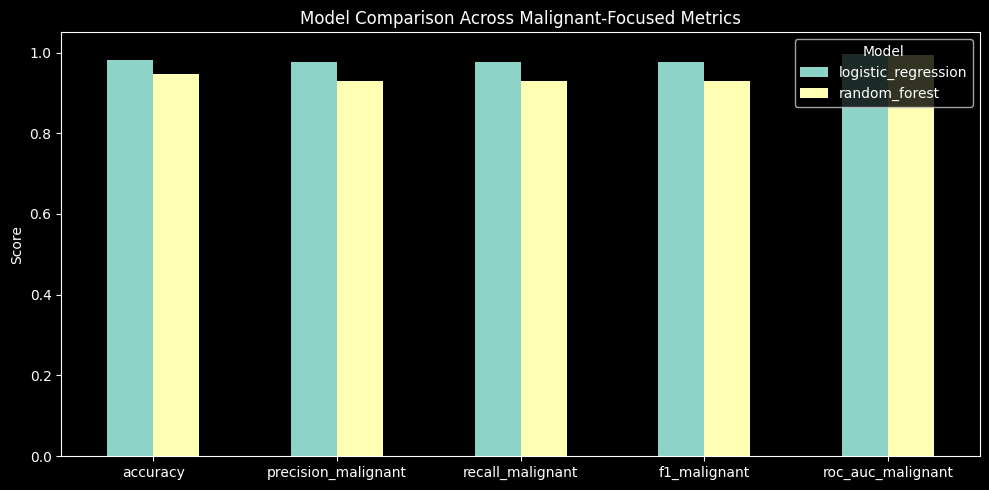

Saved comparison plot to artifacts\comparison\model_comparison.png
Logged comparison plot to MLflow summary run: 3b081e81e86041a19b80137fcfe038de


In [14]:
metric_columns = [
    "accuracy",
    "precision_malignant",
    "recall_malignant",
    "f1_malignant",
    "roc_auc_malignant",
]

comparison_plot = comparison_df.set_index("model")[metric_columns].T
plot_path = ARTIFACTS_DIR / "model_comparison.png"
comparison_csv_path = ARTIFACTS_DIR / "model_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

fig, ax = plt.subplots(figsize=(10, 5))
comparison_plot.plot(kind="bar", ax=ax)

ax.set_title("Model Comparison Across Malignant-Focused Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.05)
ax.set_xticklabels(comparison_plot.index, rotation=0)
ax.legend(title="Model")

plt.tight_layout()
fig.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()
plt.close(fig)

with mlflow.start_run(run_name="model_comparison_summary") as run:
    summary_run_id = run.info.run_id
    mlflow.set_tag("run_type", "summary")
    mlflow.set_tag("dataset", DATASET_NAME)
    mlflow.set_tag("demo_type", "classical_ml_baseline")
    mlflow.set_tag("selection_metric", "f1_malignant")
    mlflow.log_param("best_model", best_model_row["model"])
    mlflow.log_param("best_run_id", best_model_row["run_id"])
    mlflow.log_param("selection_metric", "f1_malignant")
    mlflow.log_metric("best_f1_malignant", float(best_model_row["f1_malignant"]))
    mlflow.log_metric("best_roc_auc_malignant", float(best_model_row["roc_auc_malignant"]))
    mlflow.log_artifact(str(plot_path), artifact_path="summary")
    mlflow.log_artifact(str(comparison_csv_path), artifact_path="summary")

print(f"Saved comparison plot to {plot_path}")
print(f"Logged comparison plot to MLflow summary run: {summary_run_id}")


### Execution note

Run the notebook from top to bottom so the summary MLflow run is created before the later comparison artifacts are logged to it.


## ROC CURVE

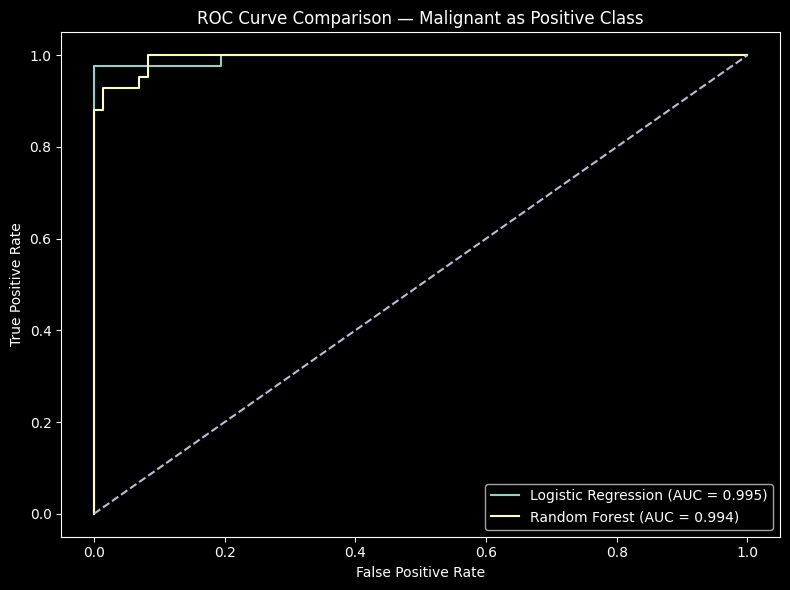

Saved ROC curve plot to artifacts\comparison\roc_curve_comparison.png
Logged ROC curve plot to MLflow summary run


In [15]:
from sklearn.metrics import roc_curve, auc

roc_plot_path = ARTIFACTS_DIR / "roc_curve_comparison.png"

lr_proba_malignant = lr_result["estimator"].predict_proba(X_test)[:, 0]
rf_proba_malignant = rf_result["estimator"].predict_proba(X_test)[:, 0]

y_test_malignant = (y_test == 0).astype(int)

lr_fpr, lr_tpr, _ = roc_curve(y_test_malignant, lr_proba_malignant)
rf_fpr, rf_tpr, _ = roc_curve(y_test_malignant, rf_proba_malignant)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
ax.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_title("ROC Curve Comparison — Malignant as Positive Class")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
fig.savefig(roc_plot_path, dpi=140, bbox_inches="tight")
plt.show()
plt.close(fig)

with mlflow.start_run(run_id=summary_run_id):
    mlflow.log_artifact(str(roc_plot_path), artifact_path="summary")

print(f"Saved ROC curve plot to {roc_plot_path}")
print("Logged ROC curve plot to MLflow summary run")


## Logistic Regression Coefficients

Visualize the most influential features in the logistic regression model based on coefficient magnitude.

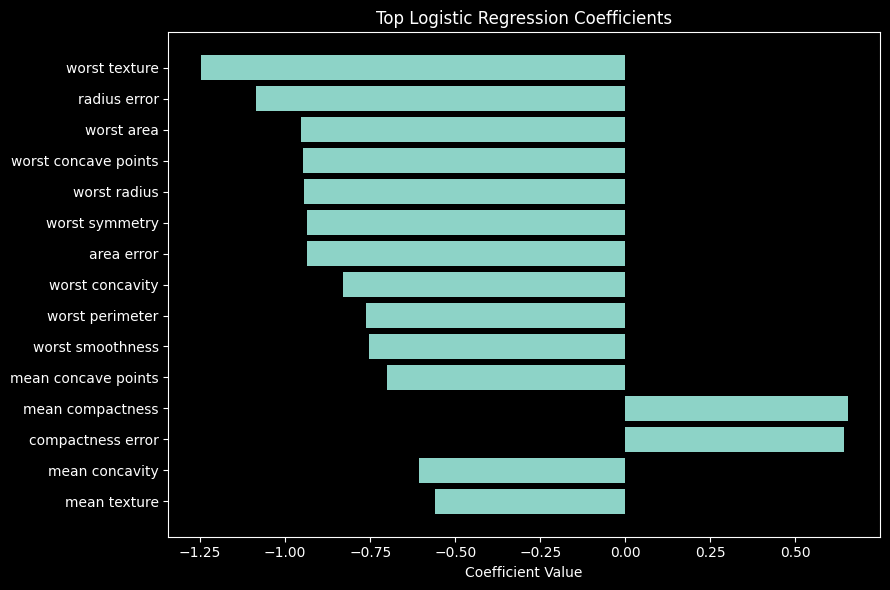

Saved coefficient plot to artifacts\comparison\logistic_regression_coefficients.png
Logged coefficient plot to MLflow summary run


In [16]:
lr_model = lr_result["estimator"].named_steps["model"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr_model.coef_[0],
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
top_coef_df = coef_df.sort_values("abs_coefficient", ascending=False).head(15)


coef_plot_path = ARTIFACTS_DIR / "logistic_regression_coefficients.png"

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coef_df["feature"], top_coef_df["coefficient"])
ax.invert_yaxis()
ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
fig.savefig(coef_plot_path, dpi=140, bbox_inches="tight")
plt.show()
plt.close(fig)

with mlflow.start_run(run_id=summary_run_id):
    mlflow.log_artifact(str(coef_plot_path), artifact_path="summary")

print(f"Saved coefficient plot to {coef_plot_path}")
print("Logged coefficient plot to MLflow summary run")


# Session 10:  How to inspect results in MLflow UI

Open the MLflow UI in your browser and inspect:

- **Experiment:** `platform-mlflow-demo`
- **Runs:**
  - `logistic-regression-baseline`
  - `random-forest-comparison`

Inside MLflow you should see:
- parameters
- metrics
- model artifacts
- confusion matrix images
- classification reports
- feature importance artifact for Random Forest


In [18]:
print("MLflow Inspection Guide")
print("-" * 60)
print(f"MLflow UI URL : {MLFLOW_UI_URL}")
print(f"Experiment    : {EXPERIMENT_NAME}")
print()

print("What to inspect in the UI:")
print("1. Runs")
print("   - Compare the logged runs for each model")
print("   - Review run names, timestamps, and parameters")
print()

print("2. Metrics")
print("   - Accuracy")
print("   - Precision")
print("   - Recall")
print("   - F1")
print("   - ROC AUC")
print()

print("3. Artifacts")
print("   - Confusion matrix")
print("   - Classification report")
print("   - Run notes / metadata")
print("   - Feature importance chart (Random Forest)")
print("   - Coefficient chart (Logistic Regression, if logged)")
print("   - Model comparison chart")
print("   - ROC curve comparison")
print()

print("4. Logged Models")
print("   - Serialized scikit-learn model artifacts")
print("   - Input example stored with each model")
print()

print("Expected outcome:")
print("You should be able to compare baseline models, inspect their artifacts,")
print("and identify the best-performing run directly from the MLflow UI.")

print()
print(f"Best model identified in this notebook: {best_model_row['model']}")
print(f"Best run ID: {best_model_row['run_id']}")

MLflow Inspection Guide
------------------------------------------------------------
MLflow UI URL : http://mlflow.localhost
Experiment    : platform-mlflow-demo

What to inspect in the UI:
1. Runs
   - Compare the logged runs for each model
   - Review run names, timestamps, and parameters

2. Metrics
   - Accuracy
   - Precision
   - Recall
   - F1
   - ROC AUC

3. Artifacts
   - Confusion matrix
   - Classification report
   - Run notes / metadata
   - Feature importance chart (Random Forest)
   - Coefficient chart (Logistic Regression, if logged)
   - Model comparison chart
   - ROC curve comparison

4. Logged Models
   - Serialized scikit-learn model artifacts
   - Input example stored with each model

Expected outcome:
You should be able to compare baseline models, inspect their artifacts,
and identify the best-performing run directly from the MLflow UI.

Best model identified in this notebook: logistic_regression
Best run ID: 6e047ef328d449c399e8c15f216f3584


### Re-running behavior

Re-running this notebook creates additional MLflow runs in the same experiment.
